In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,auc
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import seaborn as sns

In [2]:
# 1. Load dataset
# wdbc.data does not have headers, so we define them
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("wdbc.data", header=None, names=columns)

In [3]:
# 2. Prepare features and target
X = data.drop(["ID", "Diagnosis"], axis=1)
y = data["Diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [4]:

# 4. Preprocessor (scaling not needed for trees, but kept for pipeline consistency)
num_features = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), num_features)],
    remainder="drop"
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        eval_metric="logloss",   # keep this
        random_state=42
    ))
])

In [7]:
# 6. Hyperparameter grid
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.1, 0.2],
    "clf__max_depth": [3, 5, 7],
    "clf__gamma": [0, 0.1, 0.5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

In [8]:
# 6. GridSearchCV (accuracy only)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",   # only accuracy
    refit=True,           # best model chosen by accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__colsample_bytree': [0.8, 1.0], 'clf__gamma': [0, 0.1, ...], 'clf__learning_rate': [0.01, 0.1, ...], 'clf__max_depth': [3, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [11]:
# 7. Top 5 results
results = pd.DataFrame(grid.cv_results_)
table = results[[
    "param_clf__n_estimators",
    "param_clf__learning_rate",
    "param_clf__max_depth",
    "param_clf__gamma",
    "param_clf__subsample",
    "param_clf__colsample_bytree",
    "mean_test_score"
]]
table = table.rename(columns={
    "param_clf__n_estimators": "n_estimators",
    "param_clf__learning_rate": "learning_rate",
    "param_clf__max_depth": "max_depth",
    "param_clf__gamma": "gamma",
    "param_clf__subsample": "subsample",
    "param_clf__colsample_bytree": "colsample_bytree",
    "mean_test_score": "Accuracy"
})
top5 = table.sort_values(by="Accuracy", ascending=False).head(5)

print("XGBoost - Top 5 Hyperparameter Trials by Accuracy")
print(top5)

XGBoost - Top 5 Hyperparameter Trials by Accuracy
     n_estimators  learning_rate  max_depth  gamma  subsample  \
47            200            0.2          5    0.0        1.0   
41            200            0.2          3    0.0        1.0   
43             50            0.2          5    0.0        1.0   
269           200            0.2          7    0.1        1.0   
263           200            0.2          5    0.1        1.0   

     colsample_bytree  Accuracy  
47                0.8  0.975824  
41                0.8  0.975824  
43                0.8  0.973626  
269               1.0  0.973626  
263               1.0  0.973626  


In [12]:
# 8. Best hyperparameters & CV accuracy
print("\nBest Hyperparameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Best Hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 1.0}
Best CV Accuracy: 0.9758241758241759


In [13]:
best_xgb = grid.best_estimator_
y_pred = best_xgb.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred))



Test Accuracy: 0.9824561403508771
Test F1 Score: 0.975609756097561
Test Precision: 1.0
Test Recall: 0.9523809523809523
Test ROC AUC: 0.9761904761904762


/tmp/ipykernel_11479/472011034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")


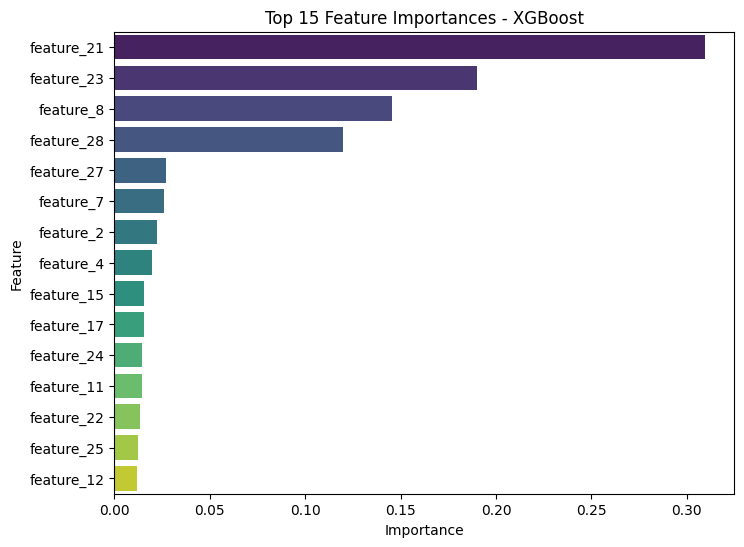

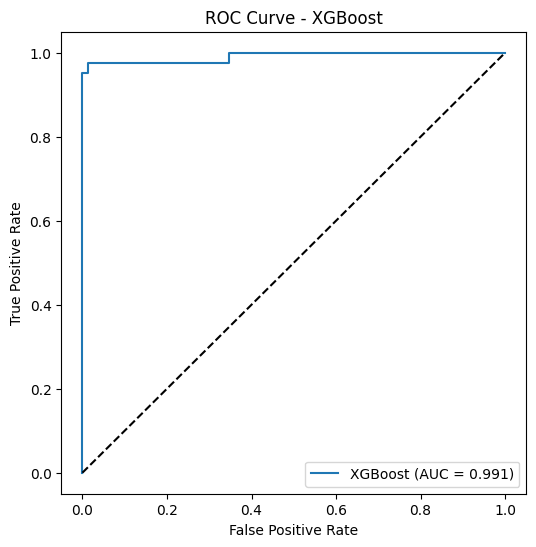

In [14]:
# --- 7. Feature Importances ---
importances = best_xgb.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)[:15]

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# --- 8. ROC Curve & AUC ---
y_prob = best_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [18]:
# Best XGBoost from GridSearch
best_xgb = XGBClassifier(
    n_estimators=grid.best_params_['clf__n_estimators'],
    learning_rate=grid.best_params_['clf__learning_rate'],
    max_depth=grid.best_params_['clf__max_depth'],
    gamma=grid.best_params_['clf__gamma'],
    subsample=grid.best_params_['clf__subsample'],
    colsample_bytree=grid.best_params_['clf__colsample_bytree'],
    eval_metric="logloss",
    random_state=42
)

# Pipeline (optional scaling)
pipe_cv = Pipeline([
    ("scaler", StandardScaler()),  # XGBoost doesn't need scaling, but kept for consistency
    ("clf", best_xgb)
])

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring="accuracy")

# Print fold accuracies and mean
for i, acc in enumerate(cv_acc, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")
print(f"Average 5-Fold CV Accuracy: {cv_acc.mean():.4f}")


Fold 1 Accuracy: 0.9780
Fold 2 Accuracy: 0.9670
Fold 3 Accuracy: 0.9670
Fold 4 Accuracy: 0.9780
Fold 5 Accuracy: 0.9890
Average 5-Fold CV Accuracy: 0.9758
